In [1]:
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import gmsh
import sys


Gmsh ist ein Netzgenerator mit zusätzlicher Funktionalität. Es lässt sich auf verschiedenen Betriebsystemen installieren und benutzen. Skripte können in einer eigenen Sprache erstellt werden, sogenannte .geo Dateinen. Es existiert auch eine gui. \
https://gmsh.info/

Eine Installation ist für die Funktion des python Paketes nicht nötig aber manchmal hilfreich, wenn man das Python Paket installiert, den die API ist dort auch verfügbar. Will man allerdings unabhängig von python das Netz betrachten/ändern oder ähnliches so kann es nützlich sein. \

Man ruft nach Installation der Gui z.B. gmsh myfile.geo auf. Gibt es diesen File nicht, so wird er erstellt und alles was im Laufe der gmsh Sitzung passiert wird abgespeichert. Man kann auch während der Sitzung diesen File ändern und mit reload die Geometrie aktualisieren. Eine sehr gute Einführung findet man unter 
https://www.youtube.com/watch?v=XrMypePGHys
https://www.youtube.com/watch?v=cQwYmk3bMSo
https://www.youtube.com/watch?v=cQwYmk3bMSo 

Das Paket kann allerdings auch über verschiedene Programmiersprachen benutzt werden, z.B Python (import gmsh). Netze oder Geometrien können auch mit der gui erstellt und dann erst geladen werden. Es gibt auch Pakete die gmsh nochmals vorgelagert sind, um die Programmierung noch einfacher zu machen (z.B. pygmsh). 

Innerhalb von jupyter kann die Darstellung des Netzes in gmsh problematisch werden, man kann hier als workaround einfach das externe Programm aufrufen (siehe unten). Ist dieser Arbeitsumgebung (visual code) funktioniert das starten aber auch direkt.

https://gmsh.info/doc/texinfo/gmsh.html

https://pypi.org/project/gmsh/

https://pypi.org/project/pygmsh/

Bei der Erstellung der Geometrie kann ein Geo-Kernel oder ein OCC (OpenCascade) Kernel benutzt werden. Der zweite weisst mehr Funktionalität als der erste auf, die Syntax variiert leicht. Insgesamt gibt es mehr Grundelemente.

die Grundidee ist zunächst eine Geometrie zu erstellen, welche aus verschiedenen Grundelementen (entities) besteht (Kreisbögen, Geraden, Punkten, Flächen, volumina). Die Elemente erhalten sogenannte tags, um Sie bei irgendwelchen Operationen (Zusammenfassungen einzelner Objekte \
oder einbetten oder transformieren,...)
identifizieren zu können. Die tags gibt man vor, oder sie werden von von gmsh automatisch erstellt, es sind im Normalfall einfach int Zahlen >0. Punkte, und Linien und Flächen, volumina können dieselben tags haben, unterscheidbar werden Sie durch die Dimension (0,1,2,3). \\
Schliesslich wird das Netz erzeugt, die Größe des Netzes lässt sich auf vielfältige Art steuern. Das Netz oder der Geometriefile kann abgespeichert werden und mit der externen gui geladen werden. Es kann ergänzt werden, oder tags können dargestellt werden. Geometrieteile können mit physical groups zusammengefasst werden.
Für Details und Beispiele empfiehlt sich die gmsh Hilfe, insbesondere die Beispiele der .geo Files in Abschnitt 2.


Nachfolgend ein konkretes Beispiel:

1) Zunächst wir eine Geometrie erstellt, also konkrete Linien, Punkte, Flächen oder Volumina. Die Objekte können werden auch mit einem Label versehen. Diese Geometrie ist zunächst unabhängig von einem Netz, es ist eine Erstellung der reinen Geometrie. In diese Gometrie werden also Linien, Punkte usw. hineinaddiert, durch synchronize() wird dann die Geometrie konkret erstellt oder auf den neusten Stand gebracht. Vor dem synchronisieren ist sie noch in einem Art Planungszustand, Verweise der tags können u.U. noch nicht existieren. Die Geometrie enthät dann die labels. Das lässt sich prüfen, indem man bei dem unten stehenden Beispiel nach öffnen der gmsh API unter tools->options->geometry 
entsprechnde Häkchen setzt (das Netz kann entsprechen unter ->tools->options->mesh konfiguriert werden).

2) Anschliessend wird das Netz erzeugt. Den Punkten (dim 0 Objekte), Kanten (dim 1 Objekte), Flächen (dim 2 Objekte) und Volumina (dim 3 Objekte) werden tags (label) zugewiesen.  
Die tags können in der API unter ->tools->options->mesh sichtbar gemacht werden. Die tags für die Meshpunkte, kanten, flächen, volumina werden von gmsh selbst definiert, sie fangen bei 1 an. 

In der API können auch Einstellungen verändert werden und dann als default (->File) oder als besondere Einstellung abgespeichert werden. 

Noch eine Bemerkung. Ein reines python programm hat hier den Vorteil, dass gmsh.fltk.run() aus dem Programm heraus auch die Geometrie anzeigt. Das Aufrufen der externen API mit dem .msh file hat den Nachteil, dass nur noch das Netz und nicht mehr die
Geometrie angezeigt werden kann. Das lässt sich umgehen, indem man z.B. direkt ein python programm mit magic command aufruft

In [2]:

gmsh.initialize()

# Name des Modells
name = 'bla' 
gmsh.model.add(name)

# Mit lc lässt sich die Netzgröße ändern
lc = 4e-2
# Definiere Punkte
gmsh.model.geo.addPoint(0, 0, 0, lc, 1)
gmsh.model.geo.addPoint(.1, 0, 0, lc, 2)
gmsh.model.geo.addPoint(.1, .1, 0, lc, 33)                  # geom. tag ist 33 für den punkt
i4 = gmsh.model.geo.addPoint(0, .1, 0, lc)                  # gmsh legt den tag/label fest
print("Beachte den Wert des gmsh zugewiesenen labels i4=",i4)
# Definiere Linien
gmsh.model.geo.addLine(1, 2, 1)
gmsh.model.geo.addLine(33, 2, 2)
gmsh.model.geo.addLine(33, i4, 3)
gmsh.model.geo.addLine(i4, 1, 100)                           # geom. tag ist 100 für die linie

# Kommentiere aus/ein
#gmsh.model.geo.addPoint(0.1, 0.04, 0, lc/4, 3)
#gmsh.model.geo.addLine(1, 3, 4)

# Erzeuge eine geschossene Kurve (addCurveLoop kann aber auch offene Kurven definieren)
gmsh.model.geo.addCurveLoop([100, 1, -2, 3], 1)              # negative Zeichen, Umlaufsinn, das ist aber kein dim=1 objekt, also keine entity   
# Erzeuge eine Fläche
gmsh.model.geo.addPlaneSurface([1], 11)                       # geometrische tag ist 11 für die fläche, dim=2 objekt
#  Erzeuge Netz
gmsh.model.geo.synchronize()
mesh = gmsh.model.mesh.generate(2)
# Speichere Daten. Die Netzdaten können dann auch wieder geladen werden.
gmsh.write(name+".msh")



# Das abgespeicherte Netz kann mit gmsh betrachtet werden. In einem *.py programm kann ein Fenster mit einer erzeugt werden. 
# In jupyter notebook scheint es nicht zu klappen
#
# if '-nopopup' not in sys.argv:
gmsh.fltk.run()
#  


# Man kann aber bei Problemen, wie oben gesagt, die externe API aufrufen, Nachteil die Geometriedetails gehen verloren
#subprocess.Popen([r"C:\Users\weju0001\Data\gmsh-4.15.0-Windows64\gmsh", "bla.msh"])




Beachte den Wert des gmsh zugewiesenen labels i4= 34


Aus dem Netz lassen sich auch bestimmte Objekte extrahieren, z.B. die Nummerierung der Dreiecke und die Punkte (sie werden aber von 1 beginnend nummeriert!). Dann kann man auch mit matplotlib zeichnen.
Es gibt \ 

Entities des Models: 

   dim=0 sind Punkte, dim=1 sind Linien, dim=2 sind Flächen, dim=3 sind Volumina \
   Mit gmesh.model.getEntities werden die topologischen Objekte ausgelesen und als Tupel ausgegeben 
   (dim,label). Der Label ist derjenige, der explizit gesetzt wurde. Insgesamt müsste sich die ganze
   Struktur abbilden. Diese Daten lassen sich auch in der API über ->tools->visibility auslesen. Auch ->tools->statistics stellt eine Übersicht dar.
   Die Koordinaten kann man über gmsh.model.getValue(dim,tag,[]) finden.

Nodes des Netzes: 

   Die Dimensionen gelten wie oben. Es werden die intern vergebenen Knotenlabel des Objektes (punkt,linie,fläche,volumen) ausgegeben. gmesh.model.mesh.getNodes kann mit dim und topologischem label aufgerufen werden. Man erhält eine Zuordnung der Knoten, sowie die zugehörigen Koordinaten. Man beachte, dass bei einer Linie nur die Knoten im Inneren der Linie und nicht die Eckpunkte ausgegeben werden. Die Eckpunkte gehören bereits zu den dim=0 Objekten. Analog sind die Meshpunkte der Fläche nur die im Inneren der Fläche. Es lassen sich auch alle Knoten ausgeben (dim=-1). Zusätzlich werden die parametrischen Koordinaten ausgegeben.  
    
Elemente des Netzes: 

   gmsh.model.mesh.getElements gibt die Elemente aus (interner label des objektes, kantennummern, Knotentupel), wobei auch hier wieder dim und topologischer 
   Label übergeben wird. In den Elementen sind hier jedoch auch die Randpunkte aufgeführt. 
   

In [70]:
#gmsh.model.getEntities()
#gmsh.model.mesh.getNodes()
#gmsh.model.mesh.getElements()

In [3]:

print("getEntities   (dim), vergleiche labels im Quelltext")
print("dim 0: Punkte :",gmsh.model.getEntities(0) )
print("dim 1: Linien :",gmsh.model.getEntities(1) )
print("dim 2 Flächen :",gmsh.model.getEntities(2) )
print("\n")

print("getNodes   (dim,labels), vergleiche labels im Quelltext")
print("dim 0, label 33",gmsh.model.mesh.getNodes(0,33),"\n")
print("dim 1, label 100",gmsh.model.mesh.getNodes(1,100),"\n")
print("dim 2, label 11",gmsh.model.mesh.getNodes(2,11),"\n")
print("\n\n")

print("getElements   (dim,labels), vergleiche labels im Quelltext")
print("dim 0, label 33",gmsh.model.mesh.getElements(0,33),"\n")
print("dim 1, label 100",gmsh.model.mesh.getElements(1,100),"\n")
print("dim 2, label 11",gmsh.model.mesh.getElements(2,11),"\n")
print("\n\n")



getEntities   (dim), vergleiche labels im Quelltext
dim 0: Punkte : [(0, 1), (0, 2), (0, 33), (0, 34)]
dim 1: Linien : [(1, 1), (1, 2), (1, 3), (1, 100)]
dim 2 Flächen : [(2, 11)]


getNodes   (dim,labels), vergleiche labels im Quelltext
dim 0, label 33 (array([3], dtype=uint64), array([0.1, 0.1, 0. ]), array([], dtype=float64)) 

dim 1, label 100 (array([11, 12], dtype=uint64), array([0.        , 0.06666667, 0.        , 0.        , 0.03333333,
       0.        ]), array([0.33333333, 0.66666667])) 

dim 2, label 11 (array([13, 14, 15, 16, 17, 18, 19, 20], dtype=uint64), array([0.06985524, 0.05      , 0.        , 0.02971334, 0.05      ,
       0.        , 0.0499281 , 0.02474399, 0.        , 0.0499281 ,
       0.07525601, 0.        , 0.07576802, 0.02423198, 0.        ,
       0.02423198, 0.07576802, 0.        , 0.02423198, 0.02423198,
       0.        , 0.07576802, 0.07576802, 0.        ]), array([0.05      , 0.06985524, 0.05      , 0.02971334, 0.02474399,
       0.0499281 , 0.07525601, 

Alle Knoten und Elemente und ein matlabplot

Node Tags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Coordinates:
 [[0.         0.         0.        ]
 [0.1        0.         0.        ]
 [0.1        0.1        0.        ]
 [0.         0.1        0.        ]
 [0.03333333 0.         0.        ]
 [0.06666667 0.         0.        ]
 [0.1        0.06666667 0.        ]
 [0.1        0.03333333 0.        ]
 [0.06666667 0.1        0.        ]
 [0.03333333 0.1        0.        ]
 [0.         0.06666667 0.        ]
 [0.         0.03333333 0.        ]
 [0.06985524 0.05       0.        ]
 [0.02971334 0.05       0.        ]
 [0.0499281  0.02474399 0.        ]
 [0.0499281  0.07525601 0.        ]
 [0.07576802 0.02423198 0.        ]
 [0.02423198 0.07576802 0.        ]
 [0.02423198 0.02423198 0.        ]
 [0.07576802 0.07576802 0.        ]]
Elements:
 [[12 13 14]
 [13 12 15]
 [10 11 13]
 [ 7  6 12]
 [ 4  5 14]
 [ 8  9 15]
 [ 9  3 17]
 [ 3 10 17]
 [11  0 18]
 [ 5  1 16]
 [ 1  7 16]
 [ 6  2 19]
 [ 2  8 19]
 [ 0  4 18]
 [13 11 18]
 

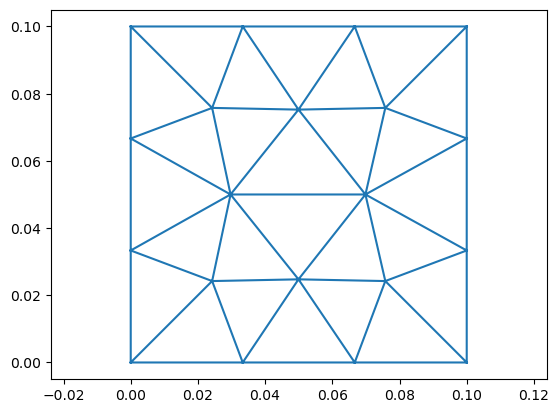

In [4]:
# Die Punkte findet man mit
# Achtung, nodeTages beginnen bei 1 und nicht bei 0
nodeTags, coords, parametricCoord = gmsh.model.mesh.getNodes()
print("Node Tags:", nodeTags)
p = np.array(coords).reshape(-1, 3)
print("Coordinates:\n", p )

# Die Elemente findet man gemäß (2=surface, objekt tag)
# object tags zeigt den typ des elementes an dreieck:2, vierecke:3, 
# element tag sind die nummern der element
# elements sind die knotentags der dreiecke, vierecke usw
objectTags, elementTags, elements = gmsh.model.mesh.getElements(2, 11)
t = elements[0].reshape(-1,3)-1   # die tags fangen bei 1 an
print("Elements:\n",t)

# Das Netz kann auch mit matplotlib betrachtet werden
plt.triplot(p[:,0],p[:,1],t)
plt.axis('equal')
plt.show()

gmsh.finalize()

Manchmal möchte man im Innern eines Gebietes Abgrenzungen haben, z.B eine Linie oder ein weiteres Recheck. Hierbei ist es wichtig, dass man die Zusatzlinien nicht nur als geometrische Linien verankert, sondern dass sie auch als Teil des Netzes definiert werden wenn das gewollt wird. Ansonsten wird es einfach eine geometrische Linien geben, aber das Netz ignoriert diese Linie. Es ist zu beachten, dass obwohl die Linien in so einem Fall nur geometrischer Natur sind, dennoch auf dieser Linie Zusatzpunkte definiert werden, die dann in gmsh.model.mesh.getNodes() erscheinen, aber nicht in der Elementliste. Das kann später zu Problemen führen, denn die die Knotenliste erhält mehr Punkte als es innerhalb des Netzes gibt.
Kommentiere folgenden Code ein/aus um das Verhalten zu beobachten.

gmsh.model.mesh.embed(1, [4], 2, 11)

gmsh.model.geo.synchronize()  


Im nachfolgenden Beispiel wird eine Linie ins Netz verankert. Man beachte, dass die Linie völlig im Inneren liegt. 

In [5]:
gmsh.initialize()

name = 'bla' 
gmsh.model.add(name)

# Mit lc lässt sich die Netzgröße ändern
lc = 5e-2
# Definiere Punkte
gmsh.model.geo.addPoint(0, 0, 0, lc, 1)
gmsh.model.geo.addPoint(.1, 0, 0, lc, 2)
gmsh.model.geo.addPoint(.1, .1, 0, lc, 33)                  
i4 = gmsh.model.geo.addPoint(0, .1, 0, lc)

# Definiere Linien
gmsh.model.geo.addLine(1, 2, 1)
gmsh.model.geo.addLine(33, 2, 2)
gmsh.model.geo.addLine(33, i4, 3)
gmsh.model.geo.addLine(i4, 1, 100)                           

# Definiere Zusatzlinie
gmsh.model.geo.addPoint(0.02, 0.01, 0, lc/3, 3)
gmsh.model.geo.addPoint(0.08, 0.04, 0, lc/3, 4)
gmsh.model.geo.addLine(3, 4, 4)

# Erzeuge eine geschossene Kurve (addCurveLoop kann aber auch offene Kurven definieren)
gmsh.model.geo.addCurveLoop([100, 1, -2, 3], 1)              
# Erzeuge eine Fläche
gmsh.model.geo.addPlaneSurface([1], 11)                       

gmsh.model.geo.synchronize()

# bette Zusatzlinie ein (Objekt ist linie :1, linie mit tag 4, soll in objekt mit dim 2 , label 11 eingebettet werden)
#gmsh.model.mesh.embed(1, [4], 2, 11)
#gmsh.model.geo.synchronize()

mesh = gmsh.model.mesh.generate(2)
# Speichere Daten. Diese Datei kann dann auch wieder geladen werden.
gmsh.write(name+".msh")



# Das abgespeicherte Netz kann mit gmsh betrachtet werden. In einem *.py programm kann ein Fenster mit einer erzeugt werden. 
# In jupyter notebook scheint es nicht zu klappen
#
# if '-nopopup' not in sys.argv:
gmsh.fltk.run()

gmsh.finalize()

Wenn man die innere Linie auf den äusseren Linien enden lassen will, dann ist es besser gemeinsame Punkte zu nutzen. Man beachte auch den Effekt von lc/3 bei Punkt 3 auf die Netzgröße. Aus den topologischen Entities werden schon mögliche Knotenpunkte des netzes angelegt

In [7]:
gmsh.initialize()

name = 'bla' 
gmsh.model.add(name)

# Mit lc lässt sich die Netzgröße ändern
lc = 5e-2
# Definiere Punkte
gmsh.model.geo.addPoint(0, 0, 0, lc, 1)
gmsh.model.geo.addPoint(.1, 0, 0, lc, 2)
gmsh.model.geo.addPoint(.1, 0.04, 0, lc/3, 3)
gmsh.model.geo.addPoint(.1, .1, 0, lc, 4)                  
gmsh.model.geo.addPoint(0, .1, 0, lc, 5)

# Definiere Linien
gmsh.model.geo.addLine(1, 2, 1)
gmsh.model.geo.addLine(2, 3, 2)
gmsh.model.geo.addLine(3, 4, 3)
gmsh.model.geo.addLine(4, 5, 4)
gmsh.model.geo.addLine(5, 1, 5)
                      
gmsh.model.geo.addLine(1, 3, 6)

# Erzeuge eine geschossene Kurve (addCurveLoop kann aber auch offene Kurven definieren)
gmsh.model.geo.addCurveLoop([1, 2, 3, 4, 5], 1)              
# Erzeuge eine Fläche
gmsh.model.geo.addPlaneSurface([1], 11)                       

gmsh.model.geo.synchronize()

# bette Zusatzlinie ein (Objekt ist linie :1, linie mit tag 4, soll in objekt mit dim 2 , label 11 eingebettet werden)
gmsh.model.mesh.embed(1, [6], 2, 11)
gmsh.model.geo.synchronize()

mesh = gmsh.model.mesh.generate(2)
# Speichere Daten. Diese Datei kann dann auch wieder geladen werden.
gmsh.write(name+".msh")



# Das abgespeicherte Netz kann mit gmsh betrachtet werden. In einem *.py programm kann ein Fenster mit einer erzeugt werden. 
# In jupyter notebook scheint es nicht zu klappen
#
# if '-nopopup' not in sys.argv:
gmsh.fltk.run()

gmsh.finalize()

Das letzte Beispiel lässt sich auch anders konstruieren, nämlich indem man zwei Flächen erzeugt und die vernetzt. Das kann Vorteile bezüglich sogenannter physikalischer Gruppen haben, die später noch zu besprechen sind. Die Definition der Punkte und der Linien bleibt erhalten, es ändert sich nur die Definition der Flächen. Es gibt keine Einbettung mehr, es liegen aber auch zwei unterscheidbare Flächen vor.

In [10]:
gmsh.initialize()

name = 'bla' 
gmsh.model.add(name)

# Mit lc lässt sich die Netzgröße ändern
lc = 5e-2
# Definiere Punkte
gmsh.model.geo.addPoint(0, 0, 0, lc, 1)
gmsh.model.geo.addPoint(.1, 0, 0, lc, 2)
gmsh.model.geo.addPoint(.1, 0.04, 0, lc/3, 3)
gmsh.model.geo.addPoint(.1, .1, 0, lc, 4)                  
gmsh.model.geo.addPoint(0, .1, 0, lc, 5)

# Definiere Linien
gmsh.model.geo.addLine(1, 2, 1)
gmsh.model.geo.addLine(2, 3, 2)
gmsh.model.geo.addLine(3, 4, 3)
gmsh.model.geo.addLine(4, 5, 4)
gmsh.model.geo.addLine(5, 1, 5)
gmsh.model.geo.addLine(1, 3, 6)

# Erzeuge zwei geschossene Kurve (addCurveLoop kann aber auch offene Kurven definieren)
gmsh.model.geo.addCurveLoop([6, 3, 4, 5], 1) 
gmsh.model.geo.addCurveLoop([1, 2, -6], 2) 

# Erzeuge zwei Fläche
gmsh.model.geo.addPlaneSurface([1], 11)    
gmsh.model.geo.addPlaneSurface([2], 12)                       

gmsh.model.geo.synchronize()

mesh = gmsh.model.mesh.generate(2)
# Speichere Daten. Diese Datei kann dann auch wieder geladen werden.
gmsh.write(name+".msh")



# Das abgespeicherte Netz kann mit gmsh betrachtet werden. In einem *.py programm kann ein Fenster mit einer erzeugt werden. 
# In jupyter notebook scheint es nicht zu klappen
#
# if '-nopopup' not in sys.argv:
gmsh.fltk.run()

gmsh.finalize()

Bislang wurde immer der Geo-Kernel benutzt. Es gibt auch noch einen OpenCascade (occ) Kernel. Der OCC-Kernel hat einen etwas größeren Funktionsumfang. So lassen sich z.B. direkt Rechtecke, Kreise, Bezierkurven uvm erzeugen, der Code wird mitunter kompakter wie am folgenden Beispiel zu sehen ist. Wenn man unten entsprechend auskommentiert, kann man zwei Rechtecke direkt nebeneinder erzeugen, allerdings gibts dann auch teilweise gleiche Punkte mehrfach. Das kann behoben werden, indem man nach Dopplungen sucht, 
```python
gmsh.model.occ.synchronize()
gmsh.model.occ.removeAllDuplicates()
gmsh.model.occ.synchronize()
```

oder indem man bei der Erzeugung schon eine entsprechende Vorkehrung trifft
```python

r1 = gmsh.model.occ.addRectangle(0, 0, 0, 1, 1) \
r2 = gmsh.model.occ.addRectangle(1, 0, 0, 1, 1) \
gmsh.model.occ.fragment([(2, r1)], [(2, r2)]) \
gmsh.model.occ.synchronize()
```

Wenn man fragment auskommentiert sieht man sofort, dass es mehrfach Punkte und Kanten gibt. Übrigens kann man bei gmsh.model.mesh.getElements(2, a) durch ändern von a die elemente des linken, des rechten oder von beiden Rechtecken extrahieren. Der Wert a=10 liefert Elemente des linken Rechtecks, a=-1 liefert die Elemente beider Rechtecke. Bei Verwendung von fertigen Objekten hat man dann aber u.U. weniger Kontrolle über das taggen/labeln der Einzelbestandteile wie z.B. Punkte oder Kanten. Sie lassen sich zwar mit gmsh.model.getBoundary([(dim, rechtecklabel)], oriented=False) abfragen, die tatsächliche Lage muss dann aber noch zusätzlich ermittelt werden. Es kann also auch günstig sein die Randkurven selbst zu machen, da dann die tags kontrollierbarer sind. Der OCC Kernel vergibt auch labels die ursprünglich mal anderen Objekten gehörten und duch Vereinigungen, Schnitte oder sonstiges von OCC zwischenzeitlich wieder frei gegeben wurden.

Node Tags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Coordinates:
 [[0.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         1.         0.        ]
 [0.         1.         0.        ]
 [2.         0.         0.        ]
 [2.         1.         0.        ]
 [0.5        0.         0.        ]
 [1.         0.5        0.        ]
 [0.5        1.         0.        ]
 [0.         0.5        0.        ]
 [1.5        0.         0.        ]
 [2.         0.5        0.        ]
 [1.5        1.         0.        ]
 [0.75       0.75       0.        ]
 [0.625      0.375      0.        ]
 [0.28125    0.28125    0.        ]
 [0.34570312 0.65429688 0.        ]
 [1.27232143 0.72767857 0.        ]
 [1.625      0.625      0.        ]
 [1.35267857 0.35565476 0.        ]
 [1.71875    0.28125    0.        ]]
Elements:
 [[ 1 14  6]
 [ 7 14  1]
 [ 3 16  8]
 [ 9 16  3]
 [ 6 15  0]
 [ 0 15  9]
 [ 2 13  7]
 [ 8 13  2]
 [13 16 14]
 [ 8 16 13]
 [13 14  7]
 [14 16 15

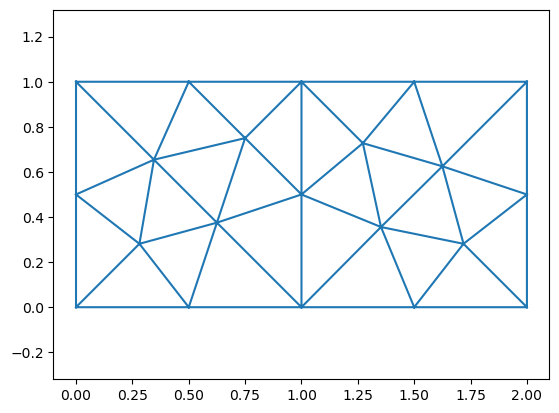

In [11]:
gmsh.initialize()

name = 'bla' 
gmsh.model.add(name)
gmsh.option.setNumber("Mesh.CharacteristicLengthMin", 0.8)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 0.8)

# Rechteck mit Rundungen kann auch damit gemacht werden (noch ein Parameter)
#gmsh.model.occ.addDisk(1.5,0.5,0,0.3,0.3,1)
gmsh.model.occ.addRectangle(0,0,0,1,1,10)
gmsh.model.occ.addRectangle(1,0,0,1,1,11)
gmsh.model.occ.fragment([(2, 10)], [(2, 11)])

gmsh.model.occ.synchronize()
mesh = gmsh.model.mesh.generate(2)
gmsh.write(name+".msh")
gmsh.fltk.run()

nodeTags, coords, parametricCoord = gmsh.model.mesh.getNodes()
print("Node Tags:", nodeTags)
p = np.array(coords).reshape(-1, 3)
print("Coordinates:\n", p )

# Die Elemente findet man gemäß (2=surface, objekt tag, -1 alle)
tp,nm,el = gmsh.model.mesh.getElements(2, -1)
t = el[0].reshape(-1,3)-1   # die tags fangen bei 1 an
print("Elements:\n",t)

# Das Netz kann auch mit matplotlib betrachtet werden
plt.triplot(p[:,0],p[:,1],t)
plt.axis('equal')
plt.show()


gmsh.finalize()



Anstelle von Dreiecken kann auch (teilweise wenn gewünscht) mit Vierecken vernetzt werden. Bei der Erzeugung der Elemente ist dann auch auf die Art der Elemente zu achten. die wird aber bei getElements zurückgegeben.

Node Tags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49]
Coordinates:
 [[0.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         1.         0.        ]
 [0.         1.         0.        ]
 [2.         0.         0.        ]
 [2.         1.         0.        ]
 [0.33333333 0.         0.        ]
 [0.66666667 0.         0.        ]
 [1.         0.25       0.        ]
 [1.         0.5        0.        ]
 [1.         0.75       0.        ]
 [0.66666667 1.         0.        ]
 [0.33333333 1.         0.        ]
 [0.         0.66666667 0.        ]
 [0.         0.33333333 0.        ]
 [1.25       0.         0.        ]
 [1.5        0.         0.        ]
 [1.75       0.         0.        ]
 [2.         0.25       0.        ]
 [2.         0.5        0.        ]
 [2.         0.75       0.        ]
 [1.75       1.         0.        ]
 [1.5        1.         0.      

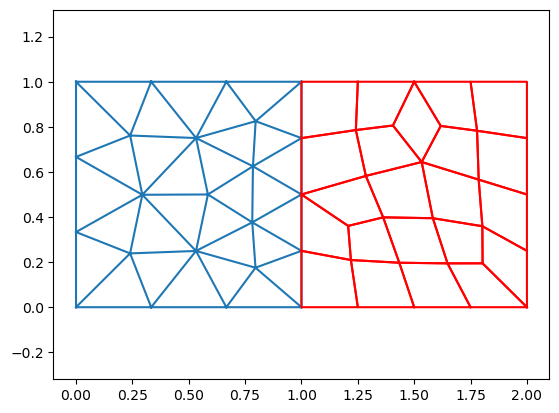

In [12]:
gmsh.initialize()

name = 'bla' 
gmsh.model.add(name)
gmsh.option.setNumber("Mesh.CharacteristicLengthMin", 0.4)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 0.4)

# Rechteck mit Rundungen kann auch damit gemacht werden (noch ein Parameter)
#gmsh.model.occ.addDisk(1.5,0.5,0,0.3,0.3,1)
gmsh.model.occ.addRectangle(0,0,0,1,1,10)
gmsh.model.occ.addRectangle(1,0,0,1,1,11)
gmsh.model.occ.fragment([(2, 10)], [(2, 11)])

gmsh.model.occ.synchronize()
gmsh.model.mesh.setRecombine(2, 11)
mesh = gmsh.model.mesh.generate(2)
gmsh.write(name+".msh")
gmsh.fltk.run()

nodeTags, coords, parametricCoord = gmsh.model.mesh.getNodes()
print("Node Tags:", nodeTags)
p = np.array(coords).reshape(-1, 3)
print("Coordinates:\n", p )

# Eine zwei im 
tp,nm,el = gmsh.model.mesh.getElements(2, -1)
print(tp)
print(nm)
print(el)
t_dreiecke = el[0].reshape(-1,3)-1
t_vierecke = el[1].reshape(-1,4)-1

plt.triplot(p[:,0],p[:,1],t_dreiecke)

# es gibt kein quadplot
for q in t_vierecke:
  x = p[q, 0]
  y = p[q, 1]
  plt.plot([x[0],x[1],x[2],x[3],x[0]], [y[0],y[1],y[2],y[3],y[0]], 'r-')

plt.axis('equal')
plt.show()  

gmsh.finalize()

Wenn das Netz abgespeichert wurde, dann kann hinterher das Netz wieder geladen werden. Das funktioniert noch nicht.

In [13]:
gmsh.initialize()
gmsh.open("bla.msh")

gmsh.fltk.run() 
gmsh.finalize()

Als nächstes wollen wir Löcher und geom. Transformationen durchführen. Als Beispiel werden 2 Rechtecke, und ein Kreis erzeugt, ein Rechteck und ein Kreis dienen als Löcher. Die ganze Anordnung wird dann gespiegelt.
Grundsätzlich ist zu beachten, dass es bei Operationen auch vorkommen kann, dass tags von Entities durch Zusammenfassen freigegeben werden und später wieder an anderer Stelle für eine andere Sache freigeben werden. 
So ist unten zu Beginn rec_a=1, rec_i=2 und disk=3, durch cut wird surf zu 2 und rec_i und disk freigeben, so dass bei copy surf_kopie zu 2 wird.    

In [16]:
gmsh.initialize()

name = 'bla' 
gmsh.model.add(name)

gmsh.option.setNumber("Mesh.CharacteristicLengthMin", 0.4)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 0.4)

# Ein Rechteck mit Linien erstellen.
ip=[]
PP = [(0,0,0),(2,0,0),(2,1,0),(0,1,0)]
for p in PP:
  ip += [ gmsh.model.occ.addPoint(*p) ]
il=[]
for i in range(4):
   il += [ gmsh.model.occ.addLine(ip[i],ip[(i+1)%4]) ]
rand = gmsh.model.occ.addCurveLoop(il)
rec_a = gmsh.model.occ.addPlaneSurface([rand])

# Rechteck mit Rundungen kann auch damit gemacht werden (noch ein Parameter)
rec_i = gmsh.model.occ.addRectangle(0.2,0.2,0,0.4,0.3,roundedRadius=0.05)
disk = gmsh.model.occ.addDisk(1.1,0.5,0,0.3,0.3)
# Ausschneiden
surf,_ = gmsh.model.occ.cut([(2, rec_a)], [(2, rec_i),(2,disk)])
# Kopie erstellen
surf_kopie = gmsh.model.occ.copy(surf)
# Transformation vornehmen
gmsh.model.occ.mirror(surf_kopie,-1, 0, 0, 0)

gmsh.model.occ.synchronize()
# Objekte verschmelzen (gemeinsame Kanten werden komplett ersetzt), es bleibt noch ein fläche übrig
#fused, _ = gmsh.model.occ.fuse(surf, surf_kopie, removeObject=True, removeTool=True)
# oder mache die kanten conform, es bleiben aber immernoch zwei flächen mit einer gemeinsamen kante
#gmsh.model.occ.fragment(surf,surf_kopie)

gmsh.model.occ.synchronize()
mesh = gmsh.model.mesh.generate(2)
gmsh.write(name+".msh")
gmsh.fltk.run()


gmsh.finalize()

oder mit dem geo Kernel. Auch hier besteht das Problem, allerdings kann man das durch gmsh.option.setNumber('Geometry.AutoCoherence', 0) ausschalten. 

"Christophe Geuzaine commented: \
The built-in kernel automatically removes duplicate entities after transformations, which in this case is problematic (the point that is not moved through the rotation is merged back to the original one). You can disable this automatic behavior with the Geometry.AutoCoherence option."

Man kommentiere diese Zeile aus und bobachte das Verhalten.

In [17]:


import numpy as np
import gmsh


gmsh.initialize()
gmsh.model.add("model1")

gmsh.option.setNumber('Geometry.AutoCoherence', 0)

lc=0.3
# points rectangle
Ps =  [(0,0,0),(2,0,0),(2,1,0),(0,1,0)]
# points inner curve 
Ps += [(1.6,0.3,0),(1.1,0.3,0),(1.1,0.8,0)]


iis=[]
# add points
for p in Ps:
    iis +=[ gmsh.model.geo.addPoint(*p,lc) ]

r1 = []
# add lines of rectangle
for i in range(4):
  r1 += [ gmsh.model.geo.addLine(iis[i], iis[(i+1)%4]) ]

c1 = []
# add inner lines
for i in range(2):
  c1 += [ gmsh.model.geo.addLine(iis[4+i], iis[4+i+1]) ]
# Falls man einen Bogen versuchen möchte statt ein Dreieck
#c1 += [ gmsh.model.geo.addCircleArc(iis[6],iis[5],iis[4]) ]
c1 += [ gmsh.model.geo.addLine(iis[6],iis[4]) ]
gmsh.model.geo.synchronize()

# make copy of inner lines
# Nach dem Kopieren gibts noch keine gemeinsamen Punkte.
c1_copy = gmsh.model.geo.copy( [(1,x) for x in c1] )
c2 = [ii[1] for ii in c1_copy]
gmsh.model.geo.synchronize()

# transformation
gmsh.model.geo.rotate( [(1,x) for x in c2],1.1,0.3,0,0,0,1,-np.pi/2.*0.2)
gmsh.model.geo.translate( [(1,x) for x in c2], -0.7,0,0 )


outer = gmsh.model.geo.addCurveLoop(r1)
inner1 = gmsh.model.geo.addCurveLoop(c1)
#inner2 = gmsh.model.geo.addCurveLoop(c2) 


surf = gmsh.model.geo.addPlaneSurface([outer, inner1])

gmsh.model.geo.synchronize()

gmsh.model.mesh.generate(2)
gmsh.fltk.run()
gmsh.finalize()


In gmsh kann die räumliche Netzgröße auf verschiedene Arten variert werden. Es gibt verschiedene Methoden.
1) Man kann auf Objekten meshpunkte erzeugen, die dann beim vernetzen benutzt werden ( z.B. TransfiniteCurve)
2) Man kann eine Funktion definieren, welche die Netzgröße vorgibt. die Funktion muss in einem string geschrieben sein
3) Man kann eine Abstandsfunktion definieren und dann das Netz anhand dieser Abstandszahl festlegen \
    a) durch eine Funktion \
    b) durch einen threshold 
4) Defintion einer boxfunktion, innerhalb/ausserhalb derer Netzgrößen gesetzt werden können  

Die Verschiedenen Methoden, MathEval, distance, Threshold, Box, Ball, ... können alle gleichzeitig gesetzt werden, da sie mit tags versehen sind. Mit 

gmsh.model.mesh.field.add("Min", 7) \
gmsh.model.mesh.field.setNumbers(7, "FieldsList", [2, 3, 5, 6])

wird das Minimum des jeweiligen lokalen Wertes verwendet.



In [18]:
gmsh.initialize()

name = 'bla' 
gmsh.model.add(name)

# Äussere Rechteckfläche
ra = gmsh.model.occ.addRectangle(0,0,0,1.5,1)
# Innere Rechteckfläche
ri = gmsh.model.occ.addRectangle(0.2,0.2,0,0.4,0.3)
gmsh.model.occ.synchronize()
# Innere Trennlinie einfügen, entweder loop machen mit lines
ri_edges = gmsh.model.getBoundary([(2,ri)], oriented=False)
ri_edges = [x[1] for x in ri_edges]
gmsh.model.mesh.embed(1, ri_edges, 2, ra )
# inneres Rechteck löschen, sonst doppelte Vernetzung
gmsh.model.occ.remove([(2, ri)])

gmsh.model.occ.synchronize()

# method 1: TransfinteCurves , 2: Formel,  3: Abstandsfkt + Formel,  4: Abstandfkt. + threshold, 5: boxfkt (innerhalb/ausserhalb)  6: kombinierte methode  
method = 6

# Mesh-Verfeinerung:
# 1) Mittels TransfiniteCurves
if method == 1:
  for line in ri_edges:
    gmsh.model.mesh.setTransfiniteCurve(line, 10)

# 2) MathEval-Field
if method == 2:
  field_tag = gmsh.model.mesh.field.add("MathEval")
  fstr = "0.05+0.2*(x*x+y*y)^2"
  gmsh.model.mesh.field.setString(field_tag,"F",fstr)
  gmsh.model.mesh.field.setAsBackgroundMesh(field_tag)

# Abstandsfunktion definieren (diese braucht dann immer noch ein Abstandsmaß z.B. Formel, threshold,..)
if method == 3:
  dist_tag = gmsh.model.mesh.field.add("Distance")
  gmsh.model.mesh.field.setNumbers(dist_tag, "EdgesList", ri_edges)       # zu diesen Linien wird der (minimale) Abstand berechnet
  gmsh.model.mesh.field.setNumber(dist_tag, "Sampling", 100)              # auf den Linien werden 100 pkt verwendet    
  # diese abstandsfunktion kann auch in einer Fkt, siehe 2) benutzt werden
  math_tag = gmsh.model.mesh.field.add("MathEval")
  gmsh.model.mesh.field.setString(math_tag, "F", "0.05 + 0.3*F%i"%(dist_tag))         # Fi = Distanzwert mit tag i
  gmsh.model.mesh.field.setAsBackgroundMesh(math_tag)


# Abstandfunktion zu einem einzelnen Punkt definieren
if method == 4 or method == 6:
  P0 = (0.75,0.6,0)
  i0 = gmsh.model.occ.addPoint(*P0)
  #zur Orientierung noch zwei kreise
  c1 = gmsh.model.occ.addCircle(*P0,0.1)
  c2 = gmsh.model.occ.addCircle(*P0,0.2)
  gmsh.model.occ.synchronize()
  gmsh.model.setColor([(1, c2)], 255,0,0,255)
  gmsh.model.setColor([(1, c1)], 0,255,0,255)
  
  # Abstand 
  dist_tag2 = gmsh.model.mesh.field.add("Distance")
  gmsh.model.mesh.field.setNumbers(dist_tag2, "PointsList", [i0])       
  # threshold
  thresh_tag = gmsh.model.mesh.field.add("Threshold")
  gmsh.model.mesh.field.setNumber(thresh_tag, "InField", dist_tag2)
  # für 0<= dist <= SizeMin : size=SizeMin
  gmsh.model.mesh.field.setNumber(thresh_tag, "DistMin", 0.1)
  gmsh.model.mesh.field.setNumber(thresh_tag, "SizeMin", 0.005)
  # für dist > SizeMax : size=SizeMax
  gmsh.model.mesh.field.setNumber(thresh_tag, "DistMax", 0.2)
  gmsh.model.mesh.field.setNumber(thresh_tag, "SizeMax", 0.1)
  if method ==5:
    gmsh.model.mesh.field.setAsBackgroundMesh(thresh_tag)
  
if method==5 or method==6:
  box_tag = gmsh.model.mesh.field.add("Box")
  gmsh.model.mesh.field.setNumber(box_tag, "VIn", 0.005)
  gmsh.model.mesh.field.setNumber(box_tag, "VOut", 0.1)
  gmsh.model.mesh.field.setNumber(box_tag, "XMin", 0.2)
  gmsh.model.mesh.field.setNumber(box_tag, "XMax", 0.6)
  gmsh.model.mesh.field.setNumber(box_tag, "YMin", 0.2)
  gmsh.model.mesh.field.setNumber(box_tag, "YMax", 0.5)
  gmsh.model.mesh.field.setNumber(box_tag, "Thickness", 0.1)
  if method==5:
    gmsh.model.mesh.field.setAsBackgroundMesh(box_tag)

if method==6:
  combined_tag = gmsh.model.mesh.field.add("Min") 
  gmsh.model.mesh.field.setNumbers(combined_tag, "FieldsList", [thresh_tag,box_tag])
  gmsh.model.mesh.field.setAsBackgroundMesh(combined_tag)


mesh = gmsh.model.mesh.generate(2)
gmsh.write(name+".msh")
gmsh.fltk.run()

gmsh.model.mesh.setTransfiniteCurve

gmsh.finalize()

In den oberen Beispielen wurde mitunter auch schon das Netz abgespeichert. Es ist zu beachten, das der .msh file nur das Netz enthält, die geometrischen Objekte sind nicht, bzw nur sehr rudimentär abgespeichert. Für den occ Kernel kann man auch noch einen .brep file abspeichern, dieser enthält die Geometriedaten. Diese Files können dann entsprechend auch wieder geladen werden.

In [20]:
gmsh.initialize()

name = 'TestSaveLoad' 
gmsh.model.add(name)

#Äusseres Rechteck
P1=(-1,-1,0); P2=(3,-1,0); P3=(3,3,0); P4=(-1,2,0)
i1=gmsh.model.occ.addPoint(*P1)
i2=gmsh.model.occ.addPoint(*P2)
i3=gmsh.model.occ.addPoint(*P3)
i4=gmsh.model.occ.addPoint(*P4)

L1=gmsh.model.occ.addLine(i1,i2)
L2=gmsh.model.occ.addLine(i2,i3)
L3=gmsh.model.occ.addLine(i3,i4)
L4=gmsh.model.occ.addLine(i4,i1)

loop1 = gmsh.model.occ.addCurveLoop([L1,L2,L3,L4])
surf1= gmsh.model.occ.addPlaneSurface([loop1])

#Inneres Rechteck
P10=(0,0,0); P11=(2,0,0); P12=(2,1,0); P13=(0,1,0)
i10=gmsh.model.occ.addPoint(*P10,tag=10)
i11=gmsh.model.occ.addPoint(*P11)
i12=gmsh.model.occ.addPoint(*P12)
i13=gmsh.model.occ.addPoint(*P13)

L10=gmsh.model.occ.addLine(i10,i11,tag=10)
L11=gmsh.model.occ.addLine(i11,i12)
L12=gmsh.model.occ.addLine(i12,i13)
L13=gmsh.model.occ.addLine(i13,i10)

gmsh.model.occ.synchronize()

gmsh.model.mesh.embed(1,[L10,L11,L12,L13],2,surf1)

gmsh.model.occ.synchronize()

mesh = gmsh.model.mesh.generate(2)
gmsh.write(name+".brep")
gmsh.write(name+".msh")
gmsh.fltk.run()

# Lese Kantenelement von geometrischer Linie L11 aus. 
el_ty, el_tag, node_tag = gmsh.model.mesh.getElements(1,L11)
print("Kantenelement L11 ist",L11,"   :   ",node_tag)

gmsh.finalize()


Kantenelement L11 ist 11    :    [array([ 6, 38, 38,  7], dtype=uint64)]


Nun wird das eben geschriebene wieder geladen. Wenn man nur den .brep file lädt, dann sieht man die Geometrie, lädt man das Netz dann sieht man nur das Netz. Unklar wie man es schafft beides gleichzeitig zu sehen.

In [21]:
gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 1) # Optionale Terminalausgabe

name = 'TestSaveLoad' 

# Lade die Geometriedaten
gmsh.open(name + ".brep") 
print("OCC entities:", gmsh.model.occ.getEntities())
gmsh.model.occ.synchronize()

# Lade Netzdaten
gmsh.open(name + ".msh")


# Hole die Kantenelemente mit dem oben definierten tag
el_ty, el_tag, node_tag = gmsh.model.mesh.getElements(1,L11)
print("Kantenelement L11 ist",L11,"   :   ",node_tag)
print("Dreieckselemente: ",gmsh.model.mesh.getElements(2,1) )


gmsh.fltk.run()

gmsh.finalize()

OCC entities: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (2, 1)]
Kantenelement L11 ist 11    :    [array([ 6, 38, 38,  7], dtype=uint64)]
Dreieckselemente:  (array([2], dtype=int32), [array([ 51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
       142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
       168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178],
      dtype=uint64)

Im nächsten Schritt sollen Teile des Netzes bestimmten Gruppen zugewiesen werden. Man möchte z.B. bestimmte Randlinien, die geometrisch an unterschiedlichen Positionen liegen zu einer Einheit zusammenfassen (Dirichletränder oder Robinränder) oder Gebiete, welche gleiche physikalische Parameter wie z.B. Leitfähigkeit, Permeabilität besitzen. Es kann auch sein, dass unterschiedliche Gebiete unterschiedlichen Lösungsverfahren hinsichtlich einer FEM oder BEM unterliegen. Man möchte also Objekte nach anderen Kriterien zusammenfassen als die geo. Lage. Zurück zu einem Anfangsbeispiel. Es sollen die beiden Randlinien, sowie die beiden Flächen in physikalische Gruppen eingeteilt werden.

In ->Tools->Visibility->Tree ist die topologische Struktur des Netzes gezeigt. Hier findet man auch die Zuweisung zu den physikalischen Gruppen

In ->Tools->Option->Geometry können durch Häkchen bei labels die Zuordnungen sichtbar gemacht werden.

In [22]:
gmsh.initialize()

name = 'TestGroups' 
gmsh.model.add(name)

#Äusseres Rechteck
P1=(-1,-1,0); P2=(3,-1,0); P3=(3,3,0); P4=(-1,2,0)
i1=gmsh.model.occ.addPoint(*P1)
i2=gmsh.model.occ.addPoint(*P2)
i3=gmsh.model.occ.addPoint(*P3)
i4=gmsh.model.occ.addPoint(*P4)

L1=gmsh.model.occ.addLine(i1,i2)
L2=gmsh.model.occ.addLine(i2,i3)
L3=gmsh.model.occ.addLine(i3,i4)
L4=gmsh.model.occ.addLine(i4,i1)

loop1 = gmsh.model.occ.addCurveLoop([L1,L2,L3,L4])
surf1= gmsh.model.occ.addPlaneSurface([loop1])

#Inneres Rechteck
P10=(0,0,0); P11=(2,0,0); P12=(2,1,0); P13=(0,1,0)
i10=gmsh.model.occ.addPoint(*P10,tag=10)
i11=gmsh.model.occ.addPoint(*P11)
i12=gmsh.model.occ.addPoint(*P12)
i13=gmsh.model.occ.addPoint(*P13)

L10=gmsh.model.occ.addLine(i10,i11,tag=10)
L11=gmsh.model.occ.addLine(i11,i12)
L12=gmsh.model.occ.addLine(i12,i13)
L13=gmsh.model.occ.addLine(i13,i10)

gmsh.model.occ.synchronize()

gmsh.model.mesh.embed(1,[L10,L11,L12,L13],2,surf1)

gmsh.model.occ.synchronize()

mesh = gmsh.model.mesh.generate(2)


# Bilde nun Gruppen, z.B. Linien
l1 = gmsh.model.addPhysicalGroup(1, [L2,L4])
gmsh.model.setPhysicalName(1, l1, "Rand_D")

l2 = gmsh.model.addPhysicalGroup(1, [L10,L11])
gmsh.model.setPhysicalName(1, l2, "Innen_1")

f1 = gmsh.model.addPhysicalGroup(2, [surf1])
gmsh.model.setPhysicalName(2, f1, "Flaeche")


r1 = gmsh.model.getEntitiesForPhysicalName("Rand_D")
for d,l in r1:
  el_ty, el_tag, node_tag = gmsh.model.mesh.getElements(d,l)
  print( node_tag[0].reshape(-1,2) ) 


print( gmsh.model.getEntitiesForPhysicalName("Innen_1") )

print("Dreiecke der Fläche :\n",gmsh.model.mesh.getElements(2,-1) )

gmsh.option.setNumber("Mesh.SaveAll", 1)
gmsh.write(name+".brep")
gmsh.write(name+".msh")
gmsh.fltk.run()

gmsh.finalize()


[[ 2 16]
 [16 17]
 [17 18]
 [18 19]
 [19 20]
 [20 21]
 [21 22]
 [22  3]]
[[ 4 30]
 [30 31]
 [31 32]
 [32 33]
 [33 34]
 [34  1]]
[(1, 10), (1, 11)]
Dreiecke der Fläche :
 (array([2], dtype=int32), [array([ 51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
       142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
       168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178],
      dtype=uint64)], [array([54, 69, 46,  8, 69, 54, 43, 47, 24, 38, 52,  7, 37, 51,  6,  8

... und wenn man nur mit dem Netz arbeiten will das zuvor abgespeichert wurde. 

Vorsicht, wenn man physikalische Gruppen abspeichert (hier z.B. Linien) dann muss auch die Fläche als Gruppe abgespeichert werden sofern man auf diese Elemente auch zugreifen will. 

Teste:
- Speichere keine phys. Gruppen ab und teste das Einlesen unten  (funktioniert, Zugriff auf Linientags L10,L11, L2,L4, surf1 usw, surf1)
- Speichere nur Linien als phys. Gruppen ab  (surf1 wird nicht mehr gefunden, node tags ist leer). Wenn Physical Groups definiert werden, dann werden nur noch die Elemente zu diesen Gruppen \
hinterlegt. Das kann durch gmsh.option.setNumber("Mesh.SaveAll", 1) verhindert werden, es werden dann alle Elemente abgespeichert.
- Speichere neben den Linien auch die Fläche als phys. Gruppe ab und teste (wieder alles da)

 

Surface entities: [(2, 1)]
Rand_D:
 [[ 1 15]
 [15 16]
 [16 17]
 [17 18]
 [18 19]
 [19 20]
 [20 21]
 [21  2]
 [ 3 29]
 [29 30]
 [30 31]
 [31 32]
 [32 33]
 [33  0]]
Innen_1:
 [[ 4 34]
 [34 35]
 [35 36]
 [36  5]
 [ 5 37]
 [37  6]]


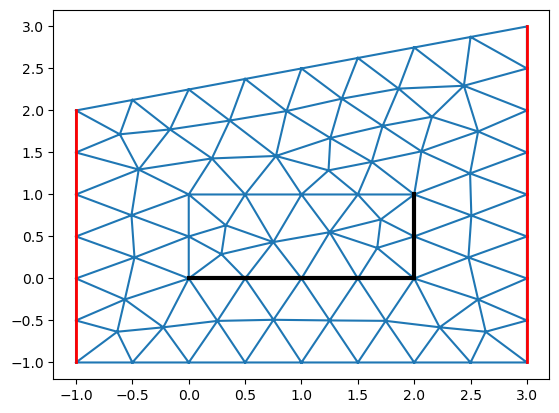

In [23]:
gmsh.initialize()

name = 'TestGroups' 

# Lade Netzdaten
gmsh.open(name + ".msh")

entities = gmsh.model.getEntities(dim=2)
print("Surface entities:", entities)

# Hole Physikalische Gruppe für Rand aussen
r1 = gmsh.model.getEntitiesForPhysicalName("Rand_D")
r1_e = []
for d,l in r1:
  el_ty, el_tag, node_tag = gmsh.model.mesh.getElements(d,l)
  r1_e.append( node_tag[0].reshape(-1,2) -1 )

# Hole physikalische Gruppe für innere Linie
r2 = gmsh.model.getEntitiesForPhysicalName("Innen_1") 
i1_e = []
for d,l in r2:
  el_ty, el_tag, node_tag = gmsh.model.mesh.getElements(d,l)
  i1_e.append( node_tag[0].reshape(-1,2) -1 )

r1_e = np.concatenate(r1_e)
print("Rand_D:\n",r1_e)
i1_e = np.concatenate(i1_e)
print("Innen_1:\n",i1_e)

# Hole Elemente für Fläche
f1 = gmsh.model.getEntitiesForPhysicalName("Flaeche")
elem_type, elem_tags, node_tags = gmsh.model.mesh.getElements(*f1[0])
tri = node_tags[0].reshape(-1,3) -1

# Hole Nodes
node_tags, coord, param_coo = gmsh.model.mesh.getNodes()
poi = coord.reshape(-1,3)[:,[0,1]]     #entferne z komponente

gmsh.finalize()

plt.triplot(poi[:,0],poi[:,1],tri)
for x in r1_e:
  plt.plot(poi[x,0],poi[x,1],'-r',lw=2)
for x in i1_e:
  plt.plot(poi[x,0],poi[x,1],'-k',lw=3)  
plt.show()


Gmsh-geo files können auch direkt in python eingelesen und dann weiter verarbeitet werden. Der Geo file kann direkt in einem Editor mit der Syntax der geo files erstellt werden. Alternativ kann auch die Gmsh-Gui verwendet werden. Man ruft gmsh -test.geo auf, es wird ein test.geo file angelegt, der entsprechend bei der Benutzung der Menüs und Objekten in der gui aktualisiert wird. Der File 3D_geo_test.geo wurde direkt mit der gui erstellt.

In [24]:
%%writefile bla.geo
//+
SetFactory("OpenCASCADE");
aa = DefineNumber[ 2, Name "aa" ];
Box(1) = {0, 0, 0, aa, aa, aa};
//+
Cylinder(2) = {aa/2, aa/2, 0, 0, 0, aa, 0.5, 2*Pi};//+
BooleanDifference{ Volume{1}; Delete; }{ Volume{2}; Delete; }
//+


Overwriting bla.geo


lade nun diesen File (noch nicht vernetzt, nur die Geometrie)

In [25]:
gmsh.initialize()

name = 'TestGroups' 

# Lade Netzdaten
gmsh.open("bla.geo")

gmsh.fltk.run()

gmsh.finalize()